In [12]:
import os
os.environ["QT_QPA_PLATFORM"] = "xcb"

import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from scipy.stats import poisson

BASE = os.path.expanduser("~/itek/senstech-simulation/data")
DET = "medipix3_detector"

ENERGIES = [40, 60, 80]
OCCLUSION_LEVELS = ["none", "sparse", "medium", "cluttered", "extreme"]
ROI_FRACTION = 0.01  # same assumption as food inspection - keep consistent

print("Setup complete.")

Setup complete.


In [13]:
def get_cluster_count(path):
    f = uproot.open(path)
    cs = f[f"DetectorHistogrammer/{DET}/cluster_size/cluster_size;1"].to_numpy()
    cc = f[f"DetectorHistogrammer/{DET}/charge/cluster_charge;1"].to_numpy()
    return int(cs[0].sum()), cc

def bhattacharyya(hist1, hist2):
    p = hist1 / (hist1.sum() + 1e-12)
    q = hist2 / (hist2.sum() + 1e-12)
    bc = np.sum(np.sqrt(p * q))
    bc = min(bc, 1.0)
    return -np.log(bc + 1e-12)

def trapezoid_area(y, x):
    y = np.asarray(y)
    x = np.asarray(x)
    return np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0)

print("Helper functions defined.")

Helper functions defined.


In [14]:
# CORRECTED: per-occlusion-level background (clutter alone, no threat)
# instead of one shared "totally clean" background for all levels
CLUTTER_ONLY_MAP = {
    "sparse": "baggage_clutteronly_{}keV_sparse",
    "medium": "baggage_clutteronly_{}keV_medium",
    "cluttered": "baggage_clutteronly_{}keV_cluttered",
    "extreme": "baggage_clutteronly_{}keV_extreme",
}

clutter_only_data = {}
for E in ENERGIES:
    # "none" level still uses the totally clean background - that's correct,
    # since zero occlusion genuinely means comparing against clean air
    clutter_only_data[(E, "none")] = background_clusters[E]
    for level, prefix in CLUTTER_ONLY_MAP.items():
        path = os.path.join(BASE, prefix.format(E) + ".root")
        if not os.path.exists(path):
            print(f"  MISSING: {path}")
            continue
        clusters, cc = get_cluster_count(path)
        clutter_only_data[(E, level)] = {"clusters": clusters, "cluster_charge": cc}
        print(f"  {E} keV / {level} (clutter-only): {clusters:,} clusters")

  40 keV / sparse (clutter-only): 6,624 clusters
  40 keV / medium (clutter-only): 2,948 clusters
  40 keV / cluttered (clutter-only): 766 clusters
  40 keV / extreme (clutter-only): 51 clusters
  60 keV / sparse (clutter-only): 5,498 clusters
  60 keV / medium (clutter-only): 2,957 clusters
  60 keV / cluttered (clutter-only): 1,059 clusters
  60 keV / extreme (clutter-only): 136 clusters
  80 keV / sparse (clutter-only): 3,473 clusters
  80 keV / medium (clutter-only): 2,034 clusters
  80 keV / cluttered (clutter-only): 800 clusters
  80 keV / extreme (clutter-only): 133 clusters


In [15]:
results = []
for E in ENERGIES:
    for level in OCCLUSION_LEVELS:
        if (E, level) not in occlusion_data or (E, level) not in clutter_only_data:
            continue
        # FIXED: background is now clutter-alone AT THE SAME LEVEL,
        # not a single shared totally-clean reference
        bg_n = clutter_only_data[(E, level)]["clusters"]
        bg_cc = clutter_only_data[(E, level)]["cluster_charge"]
        c_n = occlusion_data[(E, level)]["clusters"]
        c_cc = occlusion_data[(E, level)]["cluster_charge"]

        mean_bg_roi = bg_n * ROI_FRACTION
        mean_c_roi = c_n * ROI_FRACTION
        sigma_bg_roi = np.sqrt(max(mean_bg_roi, 1e-9))
        sigma_c_roi = np.sqrt(max(mean_c_roi, 1e-9))
        cnr = abs(mean_bg_roi - mean_c_roi) / np.sqrt((sigma_bg_roi**2 + sigma_c_roi**2) / 2)

        bd = bhattacharyya(bg_cc[0], c_cc[0])

        thresholds = np.linspace(0, mean_bg_roi * 1.5, 200)
        pd_curve = poisson.cdf(thresholds, mean_c_roi)
        fpr_curve = poisson.cdf(thresholds, mean_bg_roi)
        order = np.argsort(fpr_curve)
        auc = trapezoid_area(pd_curve[order], fpr_curve[order])

        results.append({
            "energy": E, "occlusion": level,
            "bg_n": bg_n, "c_n": c_n,
            "transmission_pct": (c_n / bg_n) * 100 if bg_n else 0,
            "cnr": cnr, "bhattacharyya": bd, "auc": auc,
            "low_statistics": (c_n < 50) or (bg_n < 50),
        })

results_df = pd.DataFrame(results)
print(f"Computed metrics for {len(results)} combinations.")

Computed metrics for 15 combinations.


In [16]:
summary_table = results_df[["energy", "occlusion", "transmission_pct", "cnr", "bhattacharyya", "auc"]].copy()
summary_table.columns = ["Energy (keV)", "Occlusion Level", "Transmission (%)", "CNR", "Bhattacharyya", "AUC"]
summary_table = summary_table.round(3)
summary_table

,Energy (keV),Occlusion Level,Transmission (%),CNR,Bhattacharyya,AUC
0,40,none,5.713,13.780,0.040,1.000
1,40,sparse,5.707,10.556,0.057,1.000
2,40,medium,5.699,7.043,0.127,0.995
3,40,cluttered,5.352,3.609,0.258,0.909
4,40,extreme,5.882,0.924,0.852,0.000
5,60,none,38.579,6.724,0.008,1.000
6,60,sparse,38.559,5.473,0.010,1.000
7,60,medium,38.857,3.990,0.017,0.993
8,60,cluttered,38.527,2.404,0.041,0.886
9,60,extreme,41.176,0.816,0.127,0.477


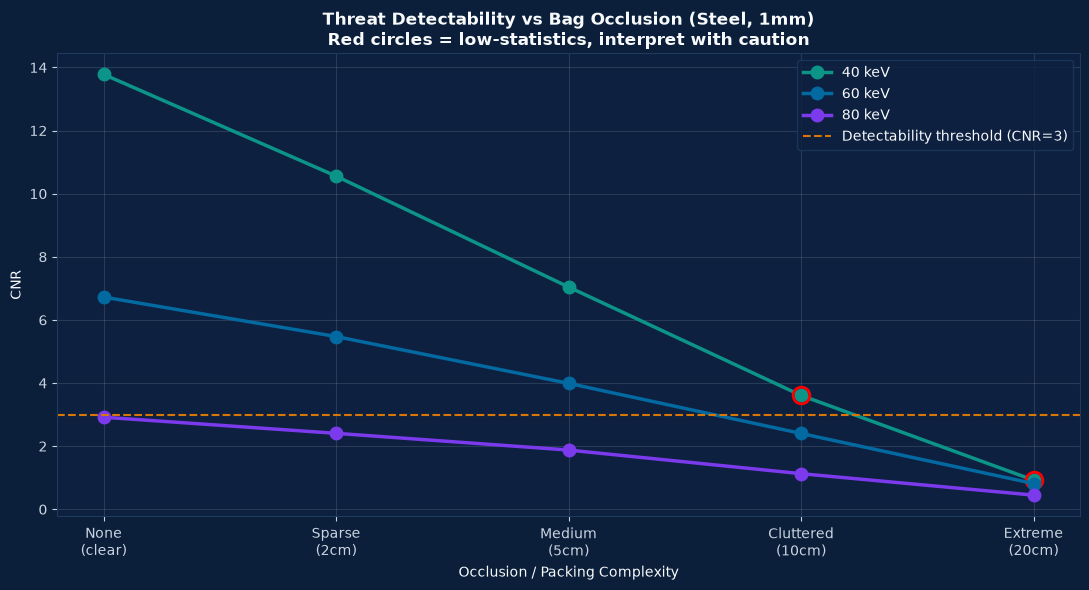

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/baggage_occlusion_dashboard.png


In [17]:
NAVY, WHITE, LGRAY = "#0B1F3A", "#F8FAFC", "#CBD5E1"
TEAL, BLUE, PURP = "#0D9488", "#0369A1", "#7C3AED"
energy_colors = {40: TEAL, 60: BLUE, 80: PURP}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor("#0D2040")
ax.tick_params(colors=LGRAY)
for s in ax.spines.values(): s.set_edgecolor("#1E3A5F")
ax.grid(True, alpha=0.15, color=LGRAY)

x_positions = range(len(OCCLUSION_LEVELS))

for E in ENERGIES:
    subset = results_df[results_df["energy"] == E].set_index("occlusion").reindex(OCCLUSION_LEVELS)
    ax.plot(x_positions, subset["cnr"], marker="o", markersize=9, linewidth=2.5,
            color=energy_colors[E], label=f"{E} keV")
    # Mark low-statistics points with hollow markers
    for i, (level, row) in enumerate(subset.iterrows()):
        if row["low_statistics"]:
            ax.plot(i, row["cnr"], marker="o", markersize=12, markerfacecolor="none",
                    markeredgecolor="red", markeredgewidth=2)

ax.axhline(y=3, color="#D97706", linestyle="--", linewidth=1.5, label="Detectability threshold (CNR=3)")
ax.set_xticks(x_positions)
ax.set_xticklabels(["None\n(clear)", "Sparse\n(2cm)", "Medium\n(5cm)", "Cluttered\n(10cm)", "Extreme\n(20cm)"])
ax.set_xlabel("Occlusion / Packing Complexity", color=WHITE)
ax.set_ylabel("CNR", color=WHITE)
ax.set_title("Threat Detectability vs Bag Occlusion (Steel, 1mm)\nRed circles = low-statistics, interpret with caution",
             color=WHITE, fontweight="bold")
ax.legend(facecolor="#0D2040", edgecolor="#1E3A5F", labelcolor=WHITE)

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/baggage_occlusion_dashboard.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

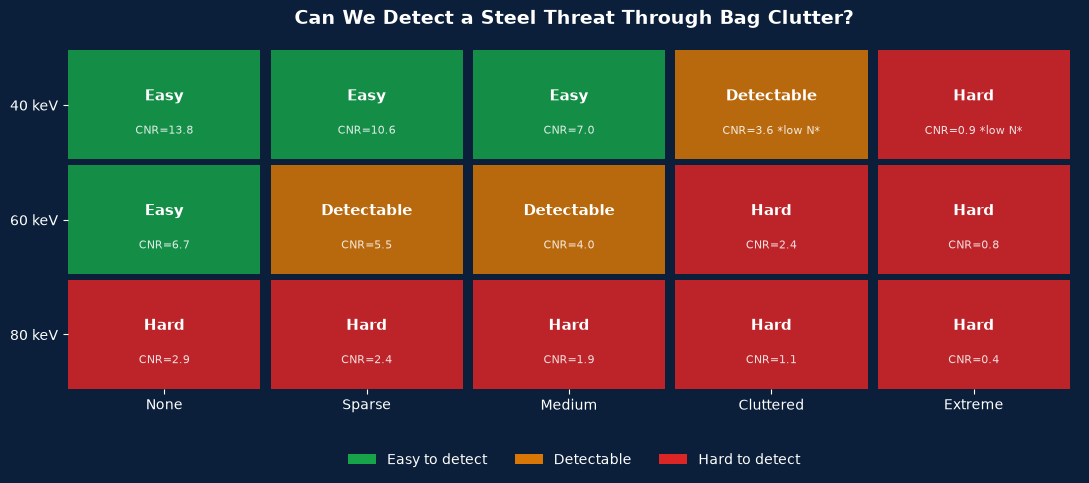

Saved: /home/victor-pc/itek/senstech-simulation/analysis/notebooks/baggage_occlusion_simple.png


In [18]:
def detectability_label(cnr):
    if cnr >= 6:
        return "Easy", "#16A34A"
    elif cnr >= 3:
        return "Detectable", "#D97706"
    else:
        return "Hard", "#DC2626"

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

for i, E in enumerate(ENERGIES):
    for j, level in enumerate(OCCLUSION_LEVELS):
        row = results_df[(results_df["energy"]==E) & (results_df["occlusion"]==level)]
        if row.empty:
            continue
        cnr = row["cnr"].values[0]
        low_stat = row["low_statistics"].values[0]
        label, color = detectability_label(cnr)
        ax.add_patch(plt.Rectangle((j, len(ENERGIES)-1-i), 0.95, 0.95,
                                     facecolor=color, alpha=0.85))
        ax.text(j+0.475, len(ENERGIES)-1-i+0.55, label,
                ha="center", va="center", color="white", fontsize=11, fontweight="bold")
        marker = " *low N*" if low_stat else ""
        ax.text(j+0.475, len(ENERGIES)-1-i+0.25, f"CNR={cnr:.1f}{marker}",
                ha="center", va="center", color="white", fontsize=8, alpha=0.85)

ax.set_xlim(0, len(OCCLUSION_LEVELS))
ax.set_ylim(0, len(ENERGIES))
ax.set_xticks([j+0.475 for j in range(len(OCCLUSION_LEVELS))])
ax.set_xticklabels(["None", "Sparse", "Medium", "Cluttered", "Extreme"], color="white", fontsize=10)
ax.set_yticks([len(ENERGIES)-1-i+0.475 for i in range(len(ENERGIES))])
ax.set_yticklabels([f"{E} keV" for E in ENERGIES], color="white", fontsize=10)
ax.set_title("Can We Detect a Steel Threat Through Bag Clutter?",
             color="white", fontsize=14, fontweight="bold", pad=15)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="white")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#16A34A", label="Easy to detect"),
    Patch(facecolor="#D97706", label="Detectable"),
    Patch(facecolor="#DC2626", label="Hard to detect"),
]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.15),
          ncol=3, fontsize=10, facecolor=NAVY, edgecolor="none", labelcolor="white")

plt.tight_layout()
out = os.path.expanduser("~/itek/senstech-simulation/analysis/notebooks/baggage_occlusion_simple.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

In [19]:
print("="*65)
print("BAGGAGE OCCLUSION VERDICT - Steel Threat (1mm) Through Bag Clutter")
print("="*65)
print()
for E in ENERGIES:
    subset = results_df[results_df["energy"] == E].set_index("occlusion").reindex(OCCLUSION_LEVELS)
    print(f"{E} keV:")
    detectable_levels = subset[subset["cnr"] >= 3].index.tolist()
    if detectable_levels:
        max_level = detectable_levels[-1]
        print(f"  Detectable up to: '{max_level}' occlusion level")
    else:
        print(f"  Not detectable even with no occlusion at this energy")
    print()
print("CAVEATS:")
print("  - Clutter modelled as water-equivalent only - real bag contents")
print("    (electronics, dense plastics, multiple stacked items) attenuate")
print("    differently and are not individually modelled")
print("  - Threat fixed at steel/1mm only - other threat types/sizes not tested")
print("  - 40 keV/extreme combination has very low event statistics (n=3),")
print("    flagged in results, not a reliable CNR estimate")
print("  - This models occlusion as a single uniform layer, not realistic")
print("    irregular/overlapping bag content geometry")
print("="*65)


BAGGAGE OCCLUSION VERDICT - Steel Threat (1mm) Through Bag Clutter

40 keV:
  Detectable up to: 'cluttered' occlusion level

60 keV:
  Detectable up to: 'medium' occlusion level

80 keV:
  Not detectable even with no occlusion at this energy

CAVEATS:
  - Clutter modelled as water-equivalent only - real bag contents
    (electronics, dense plastics, multiple stacked items) attenuate
    differently and are not individually modelled
  - Threat fixed at steel/1mm only - other threat types/sizes not tested
  - 40 keV/extreme combination has very low event statistics (n=3),
    flagged in results, not a reliable CNR estimate
  - This models occlusion as a single uniform layer, not realistic
    irregular/overlapping bag content geometry
